In [156]:
# Installazione delle librerie Python necessarie per il progetto
%pip install kagglehub matplotlib scikit-learn pandas keras numpy tensorflow seaborn

Note: you may need to restart the kernel to use updated packages.


# Analisi Dataset

Setup iniziale per la creazione della directory dove salvare le visualizzazioni generate durante l'analisi.

In [157]:
import os

# Crea la cartella per salvare i grafici generati
os.makedirs("images", exist_ok=True)

Caricamento del dataset dal repository UCI e preparazione del DataFrame per l'analisi esplorativa.

In [158]:
import kagglehub
import numpy as np
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("sulianova/cardiovascular-disease-dataset")

# Utilizza il dataset cardio_train.csv
df = pd.read_csv(os.path.join(path, "cardio_train.csv"), sep=";")
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


Adattamento delle feature a misure standard

In [159]:
df["gender"] = df["gender"] - 1 # Converti il gender da 1,2 a 0,1
df["height"] = df["height"] / 100  # Converti altezza da cm a m
df["age"] = df["age"] / 365.25  # Converti età da giorni a anni
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.357290,1,1.68,62.0,110,80,1,1,0,0,1,0
1,1,55.381246,0,1.56,85.0,140,90,3,1,0,0,1,1
2,2,51.627652,0,1.65,64.0,130,70,3,1,0,0,0,1
3,3,48.249144,1,1.69,82.0,150,100,1,1,0,0,1,1
4,4,47.841205,0,1.56,56.0,100,60,1,1,0,0,0,0


Analisi preliminare dei tipi di dati

In [160]:
# Mostra i tipi di dato di ciascuna feature
df.dtypes

id               int64
age            float64
gender           int64
height         float64
weight         float64
ap_hi            int64
ap_lo            int64
cholesterol      int64
gluc             int64
smoke            int64
alco             int64
active           int64
cardio           int64
dtype: object

### Gestione delle Feature

In [161]:
# Rimuove ID (non predittivo)
df = df.drop(columns=["id"]).copy()

# Definizione dei tipi di feature
numeric_features = ["age", "height", "weight", "ap_hi", "ap_lo"]
binary_features = ["gender", "smoke", "alco", "active"]
ordinal_features = ["cholesterol", "gluc"]

print(f"Feature numeriche: {numeric_features}")
print(f"Feature binarie: {binary_features}")
print(f"Feature ordinali: {ordinal_features}")

Feature numeriche: ['age', 'height', 'weight', 'ap_hi', 'ap_lo']
Feature binarie: ['gender', 'smoke', 'alco', 'active']
Feature ordinali: ['cholesterol', 'gluc']


In [162]:
# Converte binary_features e ordinal_features in tipo 'category'
for col in binary_features + ordinal_features:
    df[col] = df[col].astype("category")

print(df.dtypes)

age             float64
gender         category
height          float64
weight          float64
ap_hi             int64
ap_lo             int64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
cardio            int64
dtype: object


## Analisi Esplorativa

### Statistiche Descrittive

In [163]:
df[numeric_features].describe()

,age,height,weight,ap_hi,ap_lo
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,53.302850,1.643592,74.205690,128.817286,96.630414
std,6.754967,0.082101,14.395757,154.011419,188.472530
min,29.563313,0.550000,10.000000,-150.000000,-70.000000
25%,48.361396,1.590000,65.000000,120.000000,80.000000
50%,53.943874,1.650000,72.000000,120.000000,80.000000
75%,58.390144,1.700000,82.000000,140.000000,90.000000
max,64.922656,2.500000,200.000000,16020.000000,11000.000000


### Rimozione Outliers

In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualizza distribuzione delle features numeriche prima della rimozione outliers
units = {"age": "anni", "height": "m", "weight": "kg", "ap_hi": "mmHg", "ap_lo": "mmHg"}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f"Boxplot: {col}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel(f"{col} ({units[col]})", fontsize=10)
    axes[idx].grid(True, alpha=0.3)

    # Calcola statistiche IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    # Aggiungi info statistiche
    axes[idx].text(
        0.02,
        0.98,
        f"Outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)",
        transform=axes[idx].transAxes,
        fontsize=9,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5),
    )

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/boxplots_before_cleaning.png", bbox_inches="tight", dpi=300)
plt.show()

print(f"\nDataset prima della rimozione outliers: {df.shape}")

KeyboardInterrupt: 

#### Pressione Sanguigna

In [ ]:
# Pulisci il dataset rimuovendo record con valori fisiologicamente impossibili
print(f"Istanze prima della pulizia: {len(df)}")

# Limiti fisiologici realistici per la pressione sanguigna
df_clean = df[
    (df["ap_hi"] > 50)
    & (df["ap_hi"] <= 250)
    & (df["ap_lo"] > 30)
    & (df["ap_lo"] <= 200)
    & (df["ap_hi"] > df["ap_lo"])
].copy()

print(f"Istanze dopo la pulizia: {len(df_clean)}")
print(
    f"Record rimossi: {len(df) - len(df_clean)} ({(len(df) - len(df_clean))/len(df)*100:.2f}%)"
)

# Aggiorna il dataframe principale
df = df_clean.copy()

Istanze prima della pulizia: 70000
Istanze dopo la pulizia: 68672
Record rimossi: 1328 (1.90%)


#### Altezza e Peso

In [ ]:
# Rimuove outliers per altezza (sotto 2.5% o sopra 97.5%)
height_lower = df["height"].quantile(0.025)
height_upper = df["height"].quantile(0.975)
df = df[(df["height"] >= height_lower) & (df["height"] <= height_upper)]

# Rimuove outliers per peso (sotto 2.5% o sopra 97.5%)
weight_lower = df["weight"].quantile(0.025)
weight_upper = df["weight"].quantile(0.975)
df = df[(df["weight"] >= weight_lower) & (df["weight"] <= weight_upper)]

print(f"Dataset dopo rimozione outliers altezza/peso: {df.shape}")

Dataset dopo rimozione outliers altezza/peso: (62701, 12)


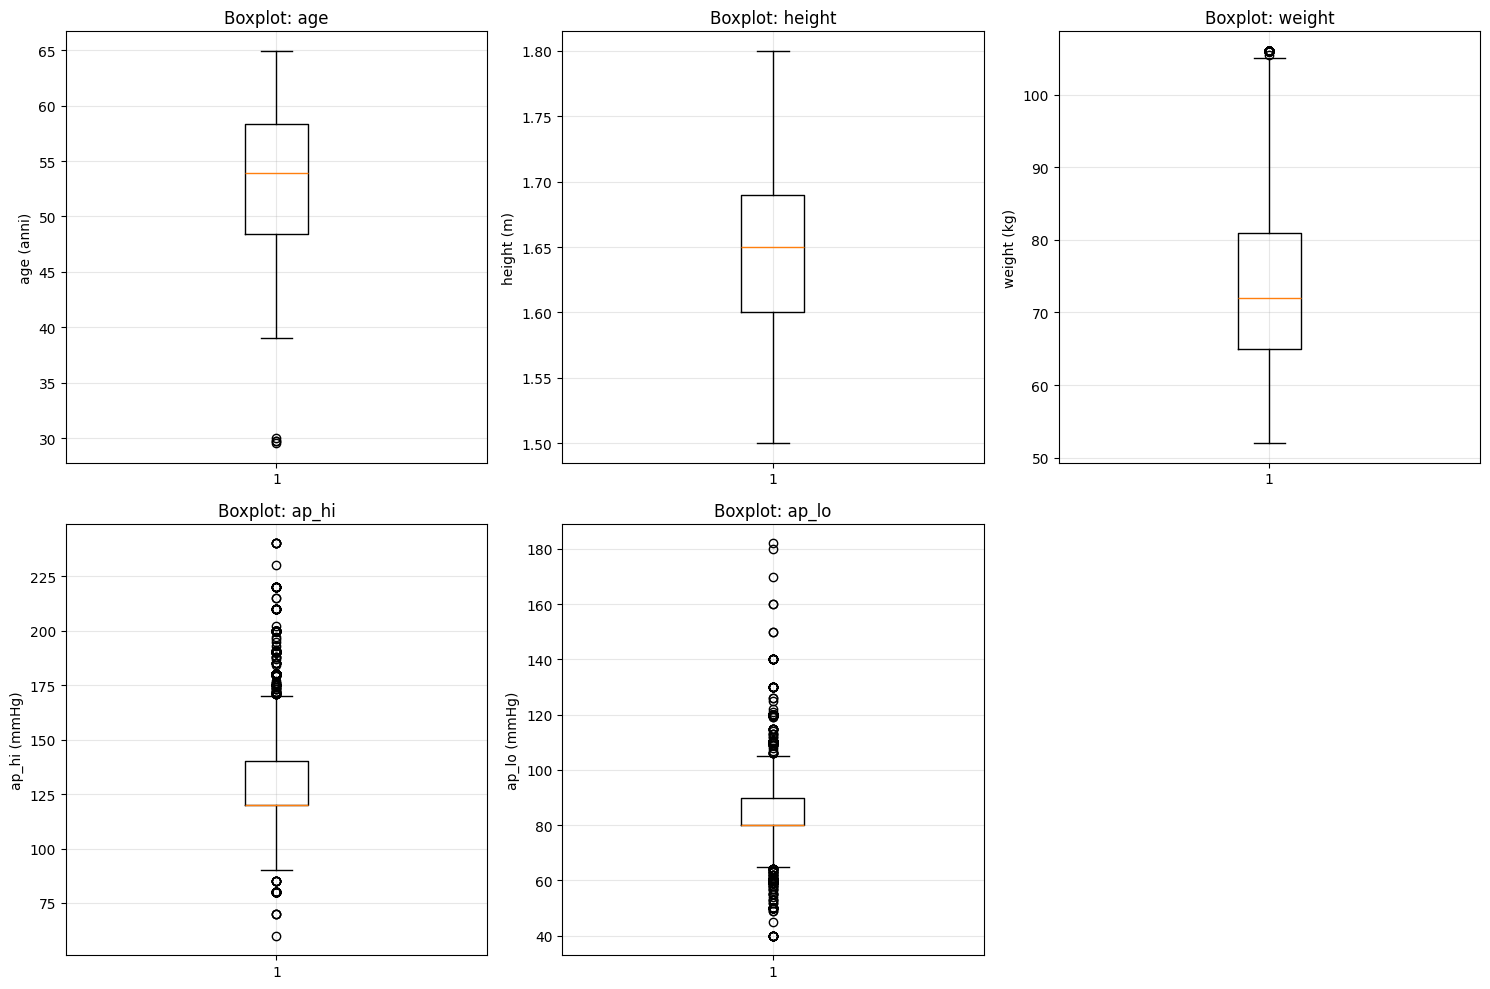

In [ ]:
# Visualizza distribuzione delle features numeriche dopo la rimozione degli outliers
units = {"age": "anni", "height": "m", "weight": "kg", "ap_hi": "mmHg", "ap_lo": "mmHg"}

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    axes[idx].boxplot(df[col].dropna())
    axes[idx].set_title(f"Boxplot: {col}")
    axes[idx].set_ylabel(f"{col} ({units[col]})")
    axes[idx].grid(True, alpha=0.3)

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/outliers_boxplots_cleaned.svg", format="svg", bbox_inches="tight")
plt.show()

### Analisi Correlazioni

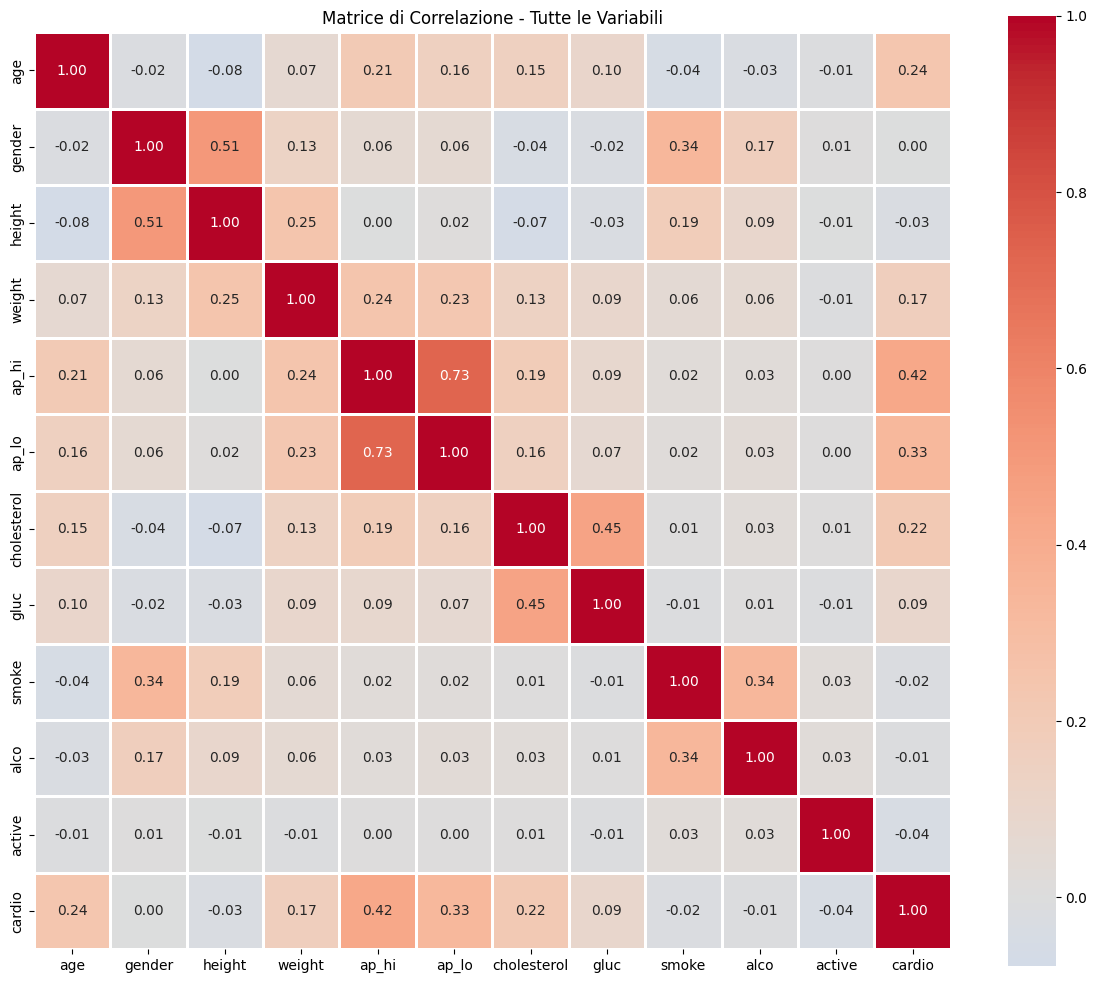


Correlazione con la variabile target (cardio):
cardio         1.000000
ap_hi          0.424727
ap_lo          0.333371
age            0.240174
cholesterol    0.218010
weight         0.166916
gluc           0.087257
gender         0.001738
alco          -0.011659
smoke         -0.020585
height        -0.025805
active        -0.037021
Name: cardio, dtype: float64


In [ ]:
# Calcola la matrice di correlazione
correlation_matrix = df.corr()

# Visualizza la matrice di correlazione con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=1,
)
plt.title("Matrice di Correlazione - Tutte le Variabili")
plt.tight_layout()
plt.savefig("images/correlation_matrix.svg", format="svg", bbox_inches="tight")
plt.show()

# Mostra le correlazioni con la variabile target (cardio) in ordine decrescente
print("\nCorrelazione con la variabile target (cardio):")
target_corr = correlation_matrix["cardio"].sort_values(ascending=False)
print(target_corr)

### Distribuzioni

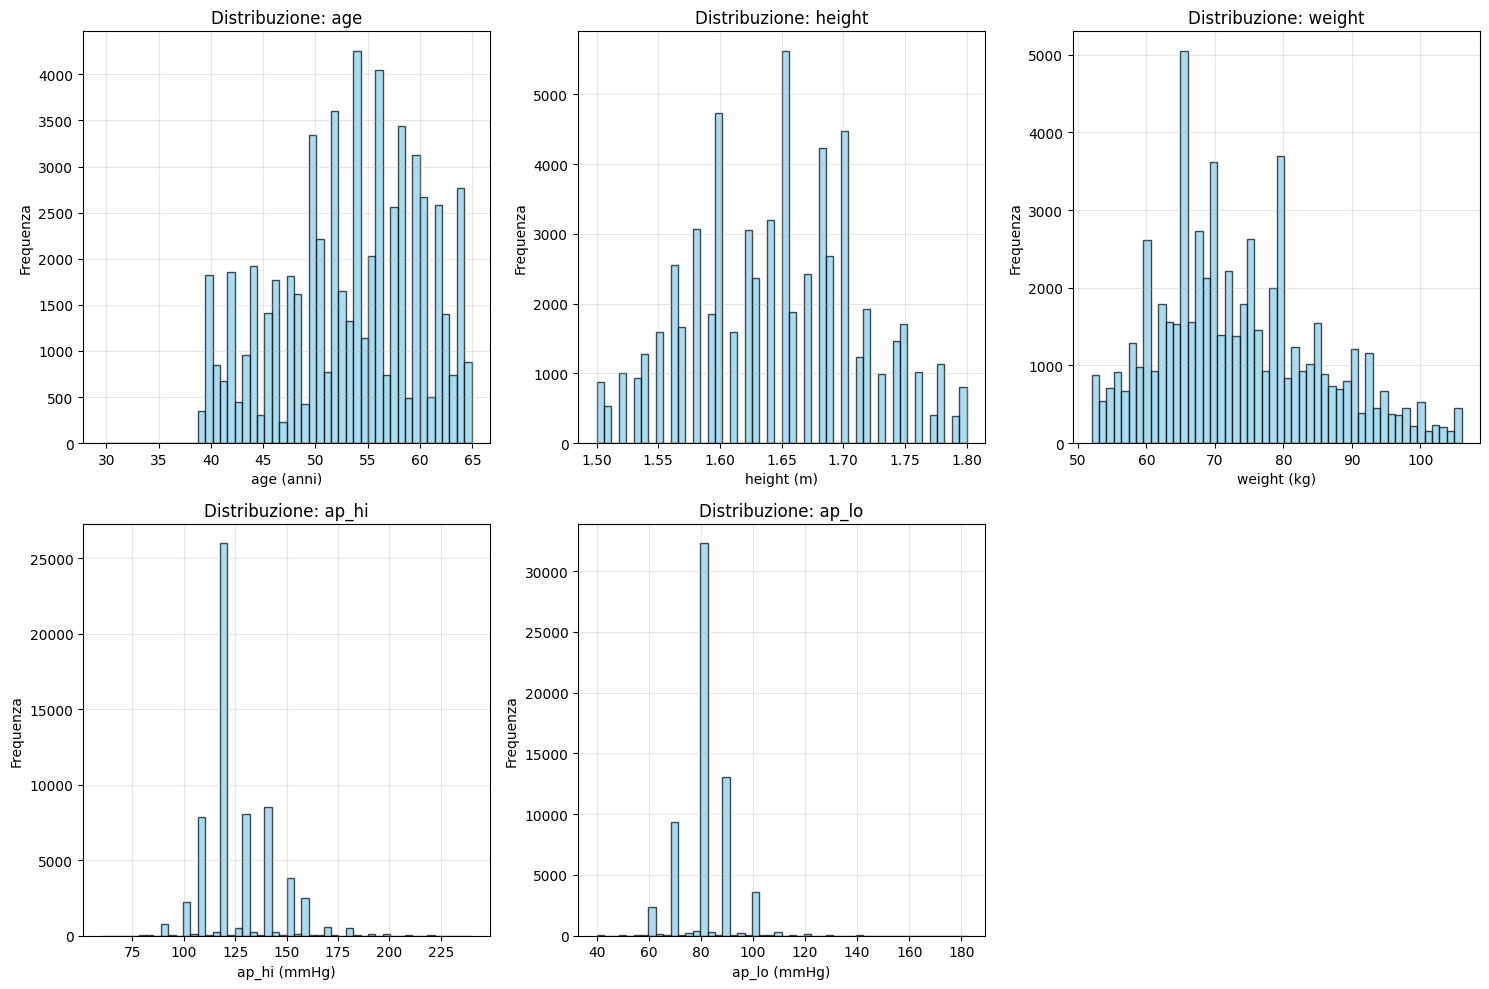

In [ ]:
# Istogrammi per le feature numeriche
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    # Usa dati convertiti per visualizzazione
    data = df[col].dropna()

    axes[idx].hist(data, bins=50, alpha=0.7, color="skyblue", edgecolor="black")
    axes[idx].set_title(f"Distribuzione: {col}")
    axes[idx].set_xlabel(f"{col} ({units[col]})")
    axes[idx].set_ylabel("Frequenza")
    axes[idx].grid(True, alpha=0.3)

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/distributions_histograms.svg", format="svg", bbox_inches="tight")
plt.show()

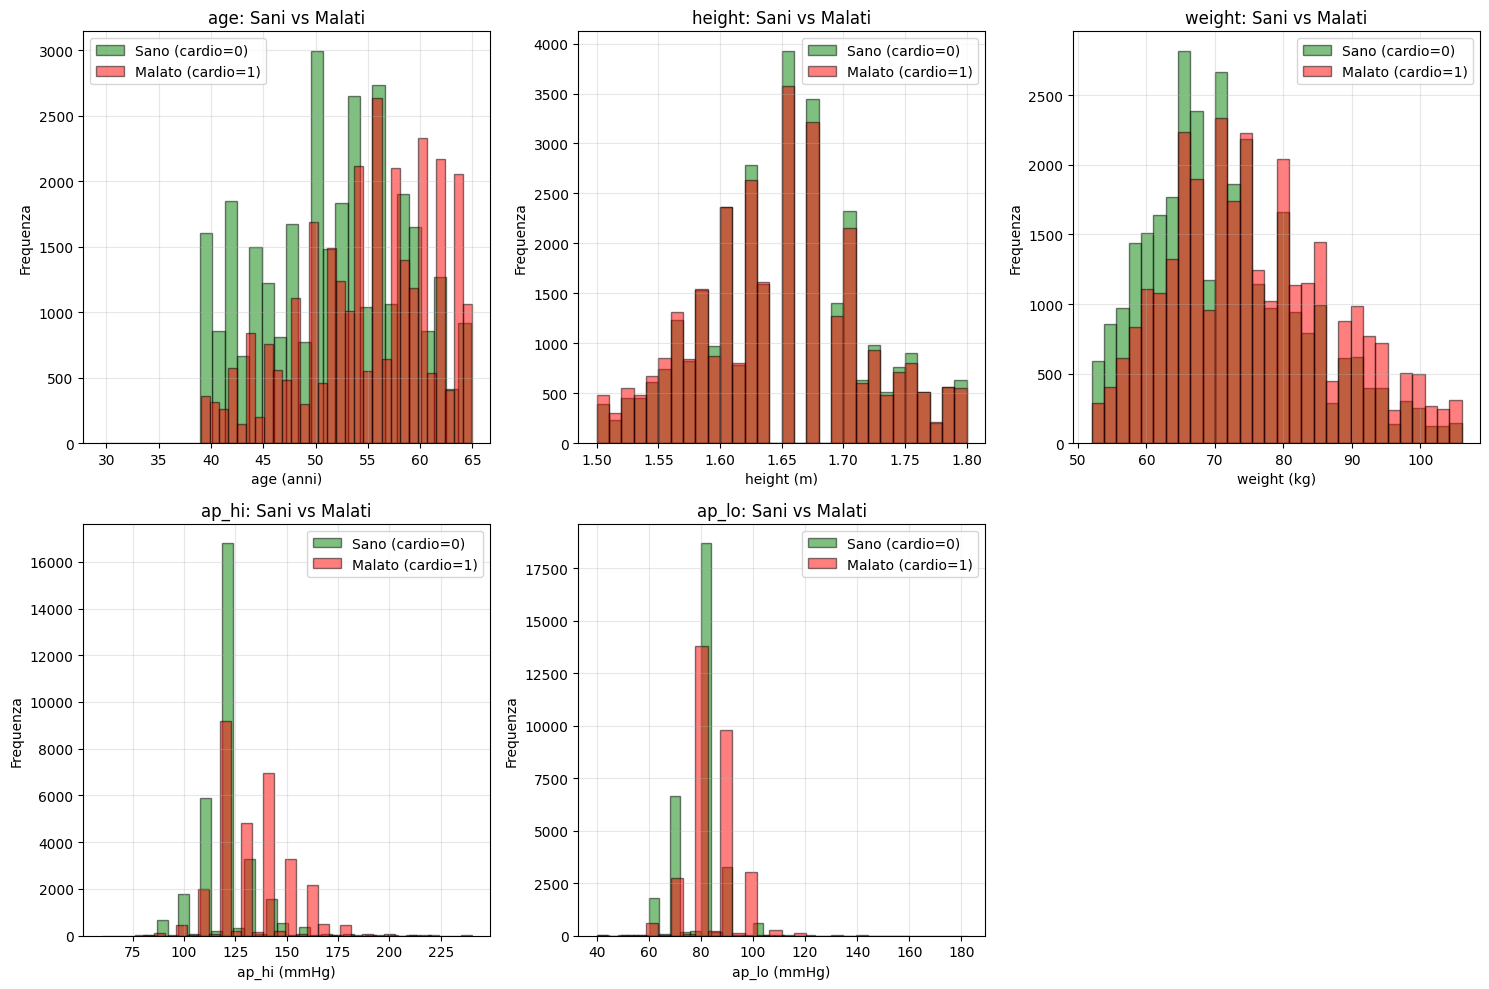

In [ ]:
# Confronto distribuzioni tra pazienti sani (cardio=0) e malati (cardio=1)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_features):
    # Separa i dati per target (usa dati convertiti)
    healthy = df[df["cardio"] == 0][col].dropna()
    sick = df[df["cardio"] == 1][col].dropna()

    axes[idx].hist(
        healthy,
        bins=30,
        alpha=0.5,
        label="Sano (cardio=0)",
        color="green",
        edgecolor="black",
    )
    axes[idx].hist(
        sick,
        bins=30,
        alpha=0.5,
        label="Malato (cardio=1)",
        color="red",
        edgecolor="black",
    )
    axes[idx].set_title(f"{col}: Sani vs Malati")
    axes[idx].set_xlabel(f"{col} ({units[col]})")
    axes[idx].set_ylabel("Frequenza")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

# Rimuovi l'ultimo subplot vuoto
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig("images/distributions_comparison.svg", format="svg", bbox_inches="tight")
plt.show()

## Preparazione Features

Dopo la pulizia del dataset, ridefinisce le features e il target usando il dataframe pulito.

In [ ]:
# Ridefinisce features e target dal dataframe pulito
features = df.drop(columns=["cardio"]).copy()
y = df["cardio"].values

print(f"Features shape: {features.shape}")
print(f"Target shape: {y.shape}")
print(features.dtypes)

Features shape: (62701, 11)
Target shape: (62701,)
age             float64
gender         category
height          float64
weight          float64
ap_hi             int64
ap_lo             int64
cholesterol    category
gluc           category
smoke          category
alco           category
active         category
dtype: object


In [ ]:
# Applica One-Hot Encoding alle feature ordinali per le reti neurali
features_nn = pd.get_dummies(
    features, columns=ordinal_features, drop_first=False, dtype=int
)

# Identifica le colonne One-Hot generate
onehot_cols = [
    col for col in features_nn.columns if col not in numeric_features + binary_features
]

# Lista completa delle feature per NN
all_features_nn = numeric_features + binary_features + onehot_cols
FEATURES_NUMBER_NN = len(all_features_nn)

print(f"\nDataset per Reti Neurali:")
print(f"  Dimensioni: {features_nn.shape}")
print(f"  Feature totali: {FEATURES_NUMBER_NN}")
print(f"  - {len(numeric_features)} numeriche")
print(f"  - {len(binary_features)} binarie")
print(f"  - {len(onehot_cols)} One-Hot encoded")
print(f"\nColonne One-Hot: {onehot_cols}")


Dataset per Reti Neurali:
  Dimensioni: (62701, 15)
  Feature totali: 15
  - 5 numeriche
  - 4 binarie
  - 6 One-Hot encoded

Colonne One-Hot: ['cholesterol_1', 'cholesterol_2', 'cholesterol_3', 'gluc_1', 'gluc_2', 'gluc_3']


In [ ]:
# Mantieni le feature ordinali come interi per Decision Tree
features_dt = features.copy()

# Converte le ordinali da category a int per interpretabilità
for col in ordinal_features:
    features_dt[col] = features_dt[col].astype(int)

# Lista completa delle feature per DT
all_features_dt = numeric_features + binary_features + ordinal_features
FEATURES_NUMBER_DT = len(all_features_dt)

# Prepara array per DT (NON SCALATO)
X_dt = features_dt[all_features_dt].values

print(f"\nDataset per Decision Tree:")
print(f"  Dimensioni: {X_dt.shape}")
print(f"  Feature totali: {FEATURES_NUMBER_DT}")
print(f"  - {len(numeric_features)} numeriche")
print(f"  - {len(binary_features)} binarie")
print(f"  - {len(ordinal_features)} ordinali (come interi)")
print(f"\nFeature ordinali come interi: {ordinal_features}")


Dataset per Decision Tree:
  Dimensioni: (62701, 11)
  Feature totali: 11
  - 5 numeriche
  - 4 binarie
  - 2 ordinali (come interi)

Feature ordinali come interi: ['cholesterol', 'gluc']


## Preparazione Dati

In [ ]:
from sklearn.preprocessing import StandardScaler

# Scala solo le feature numeriche
scaler = StandardScaler()
numeric_scaled = scaler.fit_transform(features_nn[numeric_features])

# Mantieni binarie e One-Hot inalterate (0/1)
binary_onehot_data = features_nn[binary_features + onehot_cols].values

# Concatena le feature scalate e non scalate
X_nn = np.concatenate([numeric_scaled, binary_onehot_data], axis=1)

print(f"Dati per Reti Neurali - Shape: {X_nn.shape}")

Dati per Reti Neurali - Shape: (62701, 15)


In [ ]:
# Calcola la distribuzione percentuale delle classi
class_distribution = df["cardio"].value_counts(normalize=True) * 100
print("Class Distribution:")
print(class_distribution)

Class Distribution:
cardio
0    50.654695
1    49.345305
Name: proportion, dtype: float64


## Splitting del Dataset

Suddivisione del dataset in training set (70%) e test set (30%) per entrambi gli approcci (NN e DT).

### Reti Neurali

In [ ]:
from sklearn.model_selection import train_test_split

# Split per Reti Neurali (dati scalati con One-Hot)
X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_nn, y, test_size=0.3, random_state=42
)

print(f"Split Reti Neurali:")
print(f"  Training: {X_train_nn.shape}, Test: {X_test_nn.shape}")

Split Reti Neurali:
  Training: (43890, 15), Test: (18811, 15)


### Decision Tree

In [ ]:
# Split per Decision Tree (dati NON scalati, ordinali come interi)
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(
    X_dt, y, test_size=0.3, random_state=42
)


print(f"\nSplit Decision Tree:")
print(f"  Training: {X_train_dt.shape}, Test: {X_test_dt.shape}")


Split Decision Tree:
  Training: (43890, 11), Test: (18811, 11)


# Reti Neurali

Importazione delle librerie necessarie per la creazione e il training delle reti neurali.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.utils import class_weight
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

Funzione di valutazione completa per analizzare le performance dei modelli di rete neurale.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV


# Valuta e visualizza le performance di un modello di rete neurale
def evaluate_and_plot(model, X_test, y_test, history, threshold=0.5, title_suffix=""):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Predice probabilità e applica threshold
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > threshold).astype("int32")

    # Calcola e visualizza matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa metriche di classificazione
    print("Report di Classificazione:")
    print(classification_report(y_test, y_pred))

    # Calcola curva ROC e AUC
    fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8, 6))
    plt.plot(
        fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})"
    )
    # Baseline random classifier
    plt.plot(
        [0, 1], [0, 1], color="navy", lw=2, linestyle="--", label="Random Classifier"
    )
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    title = "Curva ROC" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(
        f"images/nn_roc_curve_{file_suffix}.svg", format="svg", bbox_inches="tight"
    )
    plt.show()

    print(f"\nAUC Score: {roc_auc:.4f}")

    # Visualizza loss e accuracy durante training
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history.get("loss", []), label="Train Loss")
    plt.plot(history.history.get("val_loss", []), label="Val Loss")
    plt.title("Model Loss" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history.get("accuracy", []), label="Train Accuracy")
    plt.plot(history.history.get("val_accuracy", []), label="Val Accuracy")
    plt.title("Model Accuracy" + (f" ({title_suffix})" if title_suffix else ""))
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        f"images/nn_training_curves_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

## Standard Dataset

Creazione e training di una rete neurale con architettura sequenziale su dataset standard non bilanciato.

In [ ]:
# Crea modello sequenziale con 2 layer nascosti
model = Sequential()

# Layer nascosti: 256 -> 64 neuroni con ReLU e Dropout
model.add(Dense(256, input_shape=(FEATURES_NUMBER_NN,), activation="relu"))
model.add(Dropout(0.3))

model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))

# Layer output con sigmoid per classificazione binaria
model.add(Dense(1, activation="sigmoid"))

# Compila con binary crossentropy e Adam optimizer
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])
model.summary()

# Training con 150 epoche, batch size 256 e validation split 10%
history = model.fit(
    X_train_nn, y_train_nn, epochs=150, batch_size=256, verbose=1, validation_split=0.1
)

c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 256)            │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,609 (80.50 KB)

 Trainable params: 20,609 (80.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7151 - loss: 0.5711 - val_accuracy: 0.7387 - val_loss: 0.5450
Epoch 2/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7265 - loss: 0.5570 - val_accuracy: 0.7393 - val_loss: 0.5412
Epoch 3/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7267 - loss: 0.5552 - val_accuracy: 0.7380 - val_loss: 0.5421
Epoch 4/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7303 - loss: 0.5527 - val_accuracy: 0.7405 - val_loss: 0.5404
Epoch 5/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7299 - loss: 0.5517 - val_accuracy: 0.7389 - val_loss: 0.5415
Epoch 6/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7290 - loss: 0.5516 - val_accuracy: 0.7430 - val_loss: 0.5419
Epoch 7/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7300 - loss: 0.5505 - val_accuracy: 0.7396 - val_loss: 0.5424
Epoch 8/150
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7302 - loss: 0.5493 - val_accu

### Risultati e Metriche

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 938us/step


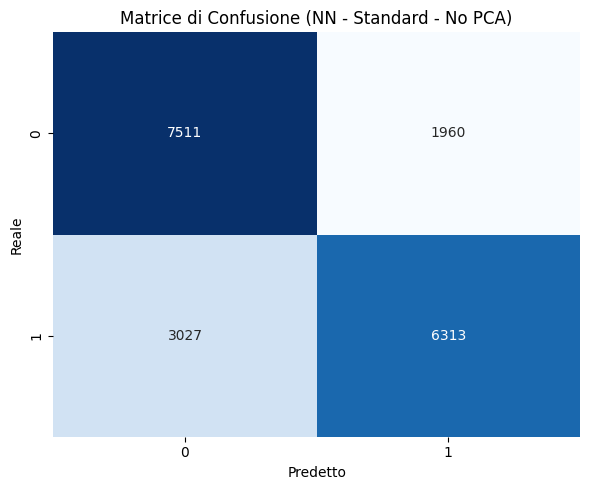

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.71      0.79      0.75      9471
           1       0.76      0.68      0.72      9340

    accuracy                           0.73     18811
   macro avg       0.74      0.73      0.73     18811
weighted avg       0.74      0.73      0.73     18811



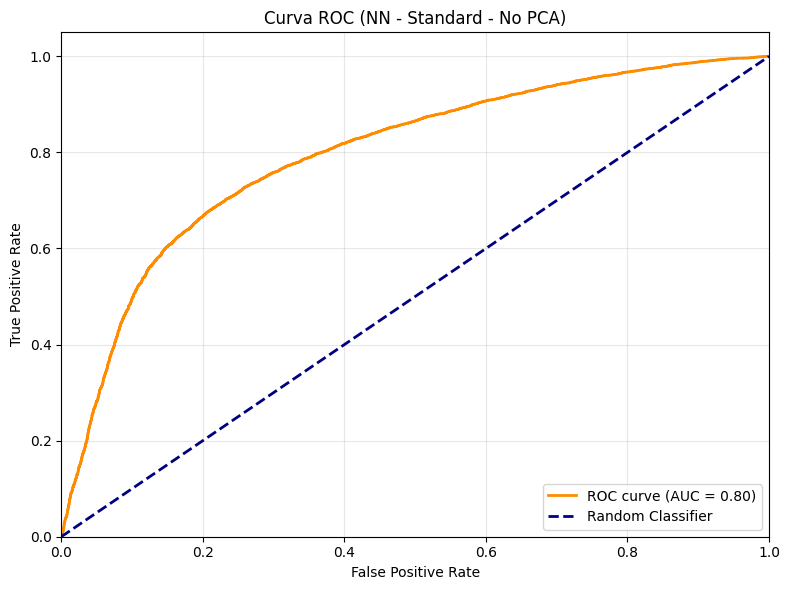


AUC Score: 0.7952


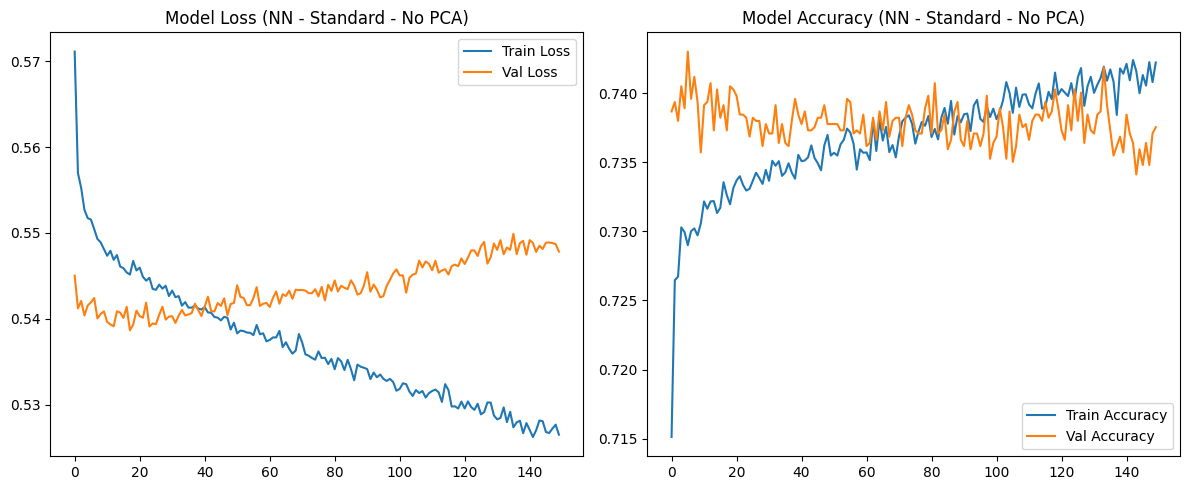

In [ ]:
# Valuta il modello e genera grafici delle metriche
evaluate_and_plot(
    model, X_test_nn, y_test_nn, history, title_suffix="NN - Standard - No PCA"
)

## Class Weight

Rete neurale addestrata con pesi di classe bilanciati per gestire lo sbilanciamento durante il training.

In [ ]:
# Calcola pesi bilanciati per le classi
class_weights_vals = class_weight.compute_class_weight(
    class_weight="balanced", classes=np.unique(y_train_nn), y=y_train_nn
)
class_weights = dict(enumerate(class_weights_vals))
print(f"Pesi delle classi: {class_weights}")

# Architettura: 256 -> 64
model_class_weights = Sequential()

model_class_weights.add(
    Dense(256, input_shape=(FEATURES_NUMBER_NN,), activation="relu")
)
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(64, activation="relu"))
model_class_weights.add(Dropout(0.3))

model_class_weights.add(Dense(1, activation="sigmoid"))

model_class_weights.compile(
    loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"]
)

# Training con class_weight - 100 epochs
history_class_weights = model_class_weights.fit(
    X_train_nn,
    y_train_nn,
    epochs=100,
    batch_size=256,
    verbose=1,
    validation_split=0.1,
    class_weight=class_weights,
)

Pesi delle classi: {0: np.float64(0.9845222072678331), 1: np.float64(1.0159722222222223)}
Epoch 1/100


c:\Users\Teo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


155/155 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7142 - loss: 0.5720 - val_accuracy: 0.7380 - val_loss: 0.5443
Epoch 2/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7259 - loss: 0.5567 - val_accuracy: 0.7371 - val_loss: 0.5422
Epoch 3/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7284 - loss: 0.5551 - val_accuracy: 0.7378 - val_loss: 0.5423
Epoch 4/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7275 - loss: 0.5529 - val_accuracy: 0.7375 - val_loss: 0.5410
Epoch 5/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7299 - loss: 0.5502 - val_accuracy: 0.7382 - val_loss: 0.5402
Epoch 6/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7299 - loss: 0.5510 - val_accuracy: 0.7409 - val_loss: 0.5414
Epoch 7/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7310 - loss: 0.5499 - val_accuracy: 0.7398 - val_loss: 0.5402
Epoch 8/100
155/155 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7305 - loss: 0.5486 - val_accuracy: 0.7421

### Risultati e Metriche

588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 933us/step


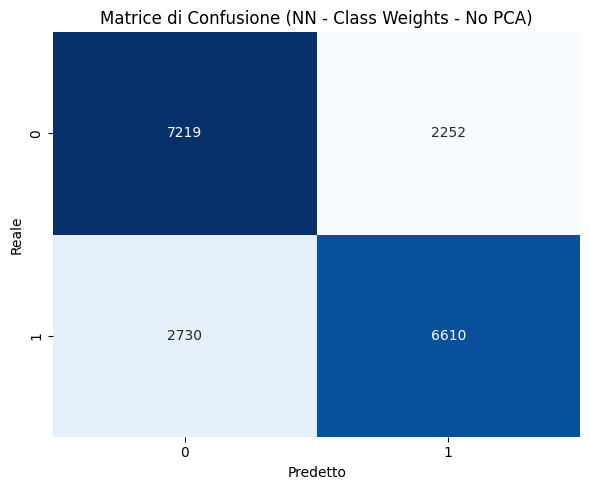

Report di Classificazione:
              precision    recall  f1-score   support

           0       0.73      0.76      0.74      9471
           1       0.75      0.71      0.73      9340

    accuracy                           0.74     18811
   macro avg       0.74      0.73      0.73     18811
weighted avg       0.74      0.74      0.73     18811



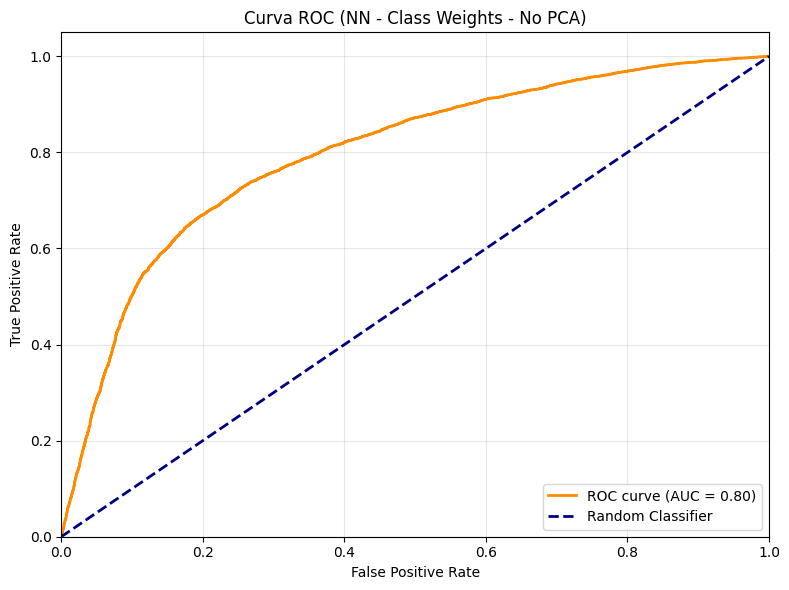


AUC Score: 0.7976


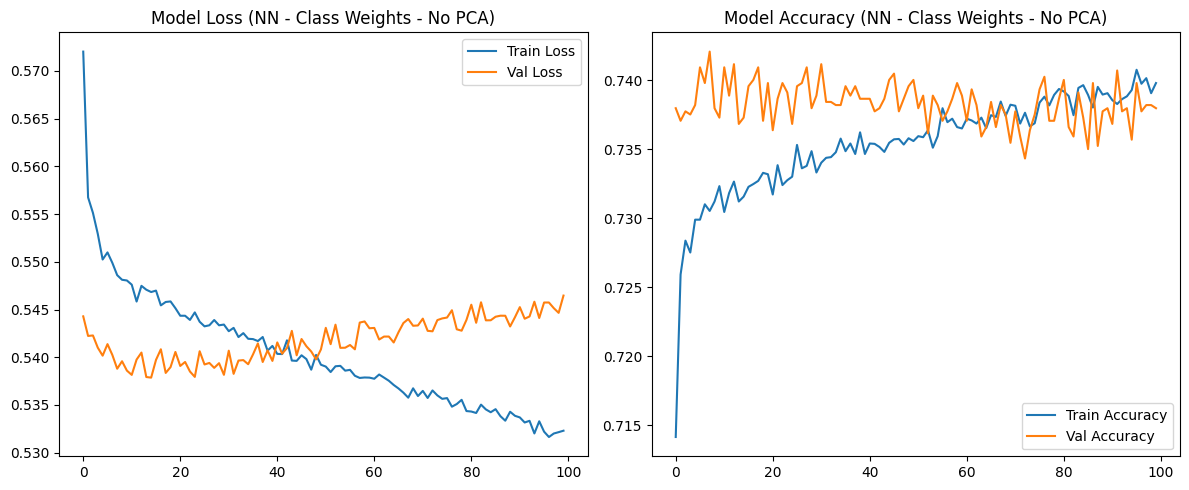

In [ ]:
# Valuta modello con class weights
evaluate_and_plot(
    model_class_weights,
    X_test_nn,
    y_test_nn,
    history_class_weights,
    threshold=0.5,
    title_suffix="NN - Class Weights - No PCA",
)

# Alberi di Decisione

Definizione delle funzioni di supporto per visualizzazione e valutazione degli alberi di decisione.

In [ ]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.tree import plot_tree, DecisionTreeClassifier
import pandas as pd


# Calcola e visualizza le metriche di performance dell'albero
def show_tree_metrics(tree, y_test, y_pred, title_suffix):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

    # Caratteristiche strutturali albero
    if hasattr(tree, "get_depth"):
        print(f"Profondità albero: {tree.get_depth()}")
        print(f"Numero di foglie: {tree.get_n_leaves()}")

    # Matrice di confusione
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    title = "Matrice di Confusione" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(
        f"images/dt_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    print("\n" + classification_report(y_test, y_pred))


# Visualizza la struttura dell'albero di decisione
def print_tree(tree, max_depth, title, feature_names):
    file_suffix = (
        title.lower().replace(" ", "_").replace("-", "") if title else "decision_tree"
    )
    plt.figure(figsize=(50, 24))

    # Genera grafico albero con nodi colorati
    plot_tree(
        tree,
        filled=True,
        feature_names=feature_names,
        class_names=["0", "1"],
        fontsize=8,
        max_depth=max_depth,
    )
    plt.title(title)
    plt.tight_layout()
    plt.savefig(f"images/dt_{file_suffix}.svg", format="svg", bbox_inches="tight")
    plt.show()

Funzione per analizzare e visualizzare l'importanza delle feature nell'albero di decisione.

In [ ]:
# Visualizza l'importanza delle feature nell'albero
def plot_feature_importance(tree, feature_names, title_suffix, top_n=None):
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Estrae feature importance dall'albero
    importances = tree.feature_importances_

    # Crea DataFrame e ordina per importanza
    importance_df = pd.DataFrame(
        {"feature": feature_names, "importance": importances}
    ).sort_values("importance", ascending=False)

    # Limita alle top_n feature
    if top_n is not None:
        importance_df = importance_df.head(top_n)

    # Crea grafico a barre orizzontali
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(importance_df)), importance_df["importance"])
    plt.yticks(range(len(importance_df)), importance_df["feature"])
    plt.xlabel("Feature Importance")
    plt.ylabel("Features")
    title = "Feature Importance" + (f" ({title_suffix})" if title_suffix else "")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(
        f"images/dt_feature_importance_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    # Stampa valori
    print(f"\nFeature Importance{' (' + title_suffix + ')' if title_suffix else ''}:")
    print(importance_df.to_string(index=False))

Funzione per eseguire Grid Search con cross-validation per trovare i migliori iperparametri.

In [ ]:
# Esegue Grid Search per trovare i migliori iperparametri
def run_grid_search(
    X_train, y_train, param_grid, class_weight="balanced", cv=5, scoring="f1"
):
    base_model = DecisionTreeClassifier(random_state=42, class_weight=class_weight)

    # Inizializza Grid Search con cross-validation
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        verbose=1,
        return_train_score=True,
    )

    grid_search.fit(X_train, y_train)

    print(f"\n{'='*60}")
    print(f"RISULTATI GRID SEARCH (scoring={scoring}, cv={cv})")
    print(f"{'='*60}")
    print(f"Migliori parametri: {grid_search.best_params_}")
    print(f"Miglior score ({scoring}): {grid_search.best_score_:.4f}")
    print(f"{'='*60}\n")

    return grid_search.best_estimator_, grid_search

Definizione della griglia di iperparametri da testare con Grid Search.

In [ ]:
# Griglia iperparametri per Grid Search
dt_param_grid = {
    "max_depth": [5, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"],
    "ccp_alpha": [0, 0.0001, 0.0005, 0.001, 0.005, 0.01],
}

## Standard Dataset

In [ ]:
# Esegue Grid Search senza class weights sui dati non scalati
dt_standard, grid_search_standard = run_grid_search(
    X_train_dt, y_train_dt, dt_param_grid, class_weight=None
)
y_pred_standard = dt_standard.predict(X_test_dt)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7199



### Risultati e Metriche

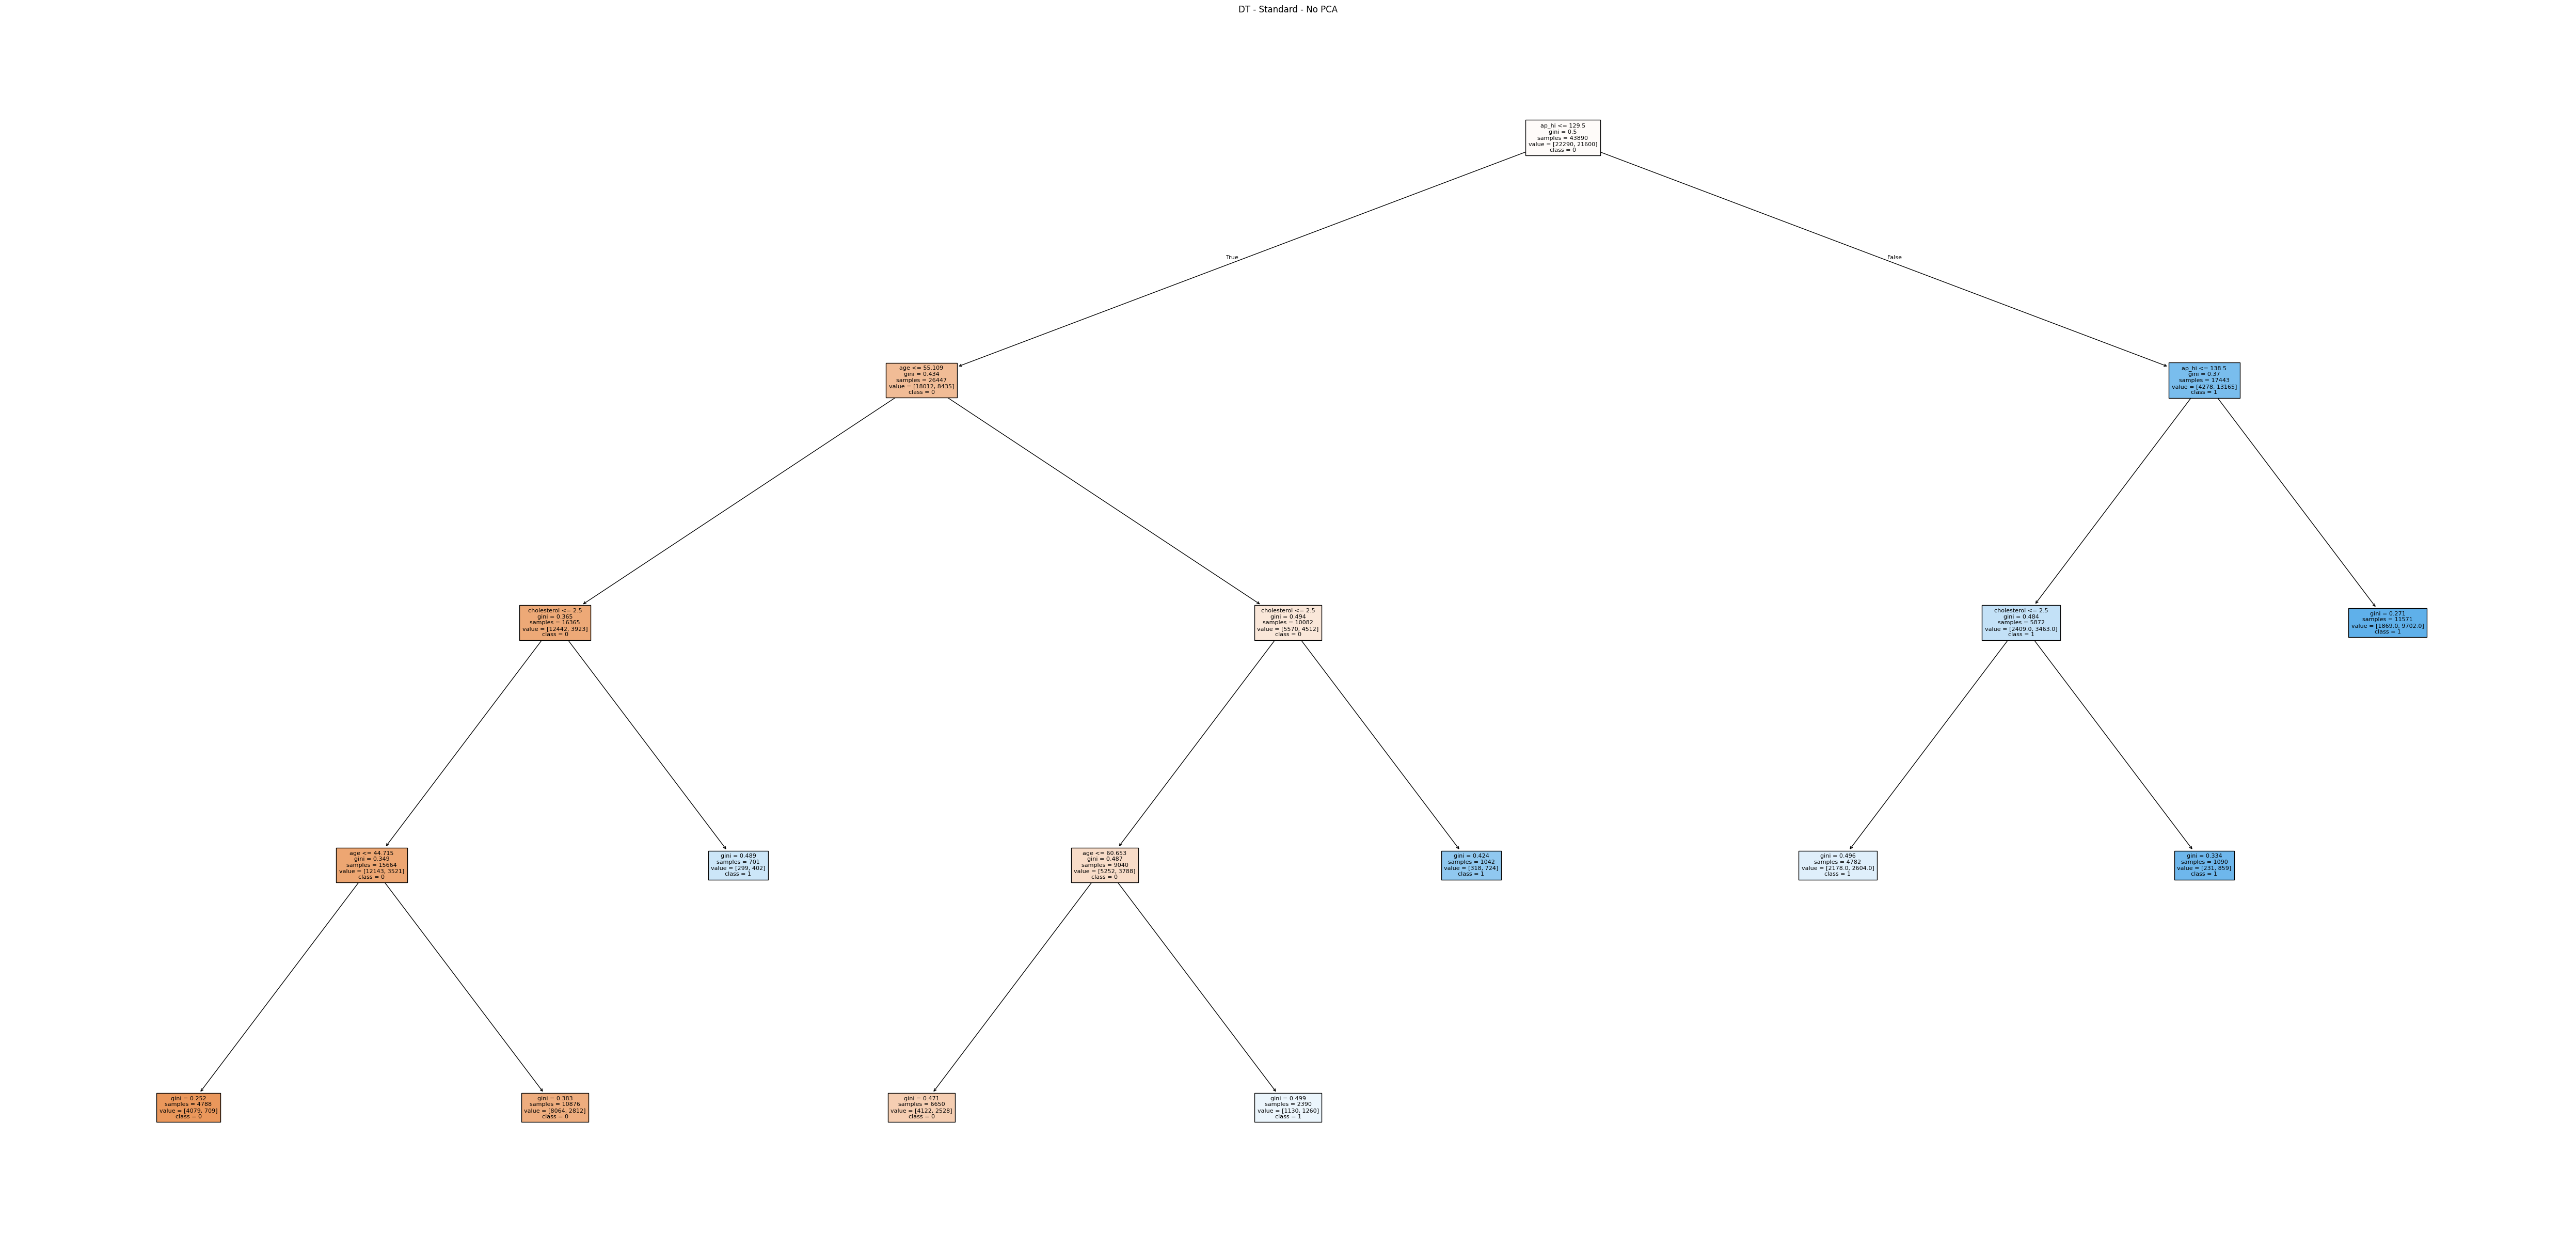

Accuracy: 0.7314
Profondità albero: 4
Numero di foglie: 9


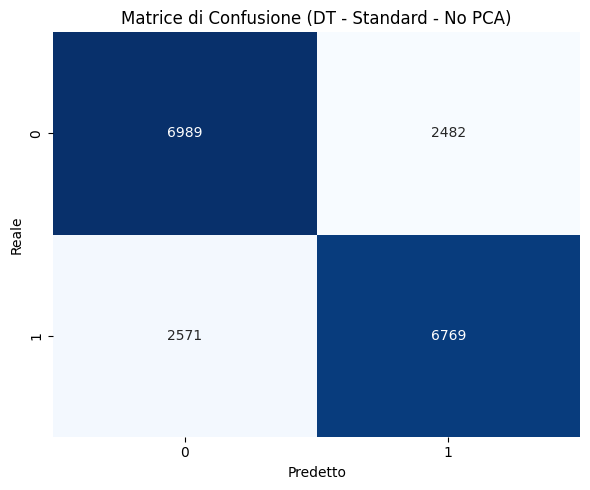


              precision    recall  f1-score   support

           0       0.73      0.74      0.73      9471
           1       0.73      0.72      0.73      9340

    accuracy                           0.73     18811
   macro avg       0.73      0.73      0.73     18811
weighted avg       0.73      0.73      0.73     18811



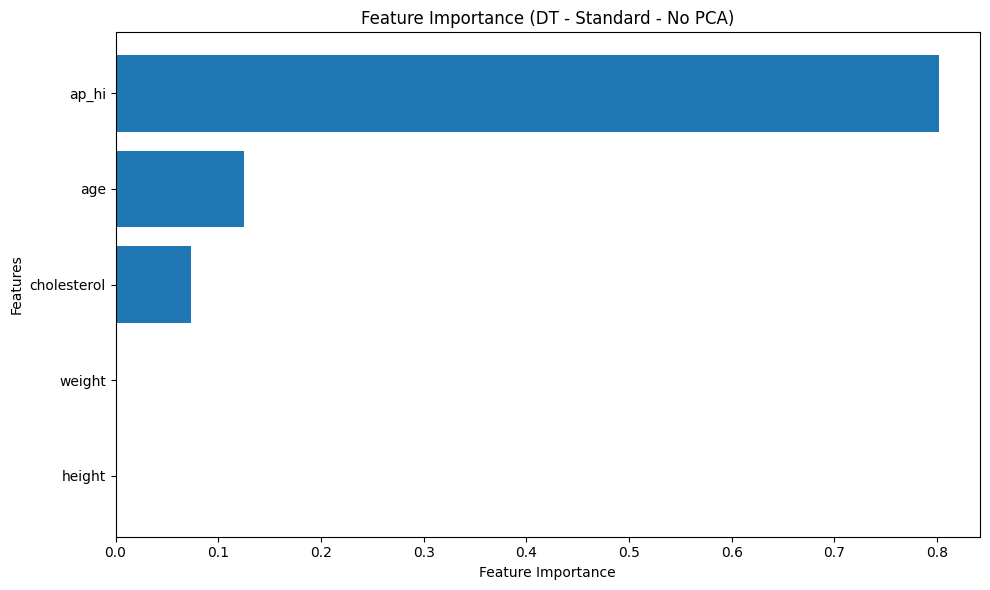


Feature Importance (DT - Standard - No PCA):
    feature  importance
      ap_hi    0.801725
        age    0.124709
cholesterol    0.073566
     weight    0.000000
     height    0.000000


In [ ]:
# Visualizza albero
print_tree(
    dt_standard,
    max_depth=dt_standard.get_depth(),
    title="DT - Standard - No PCA",
    feature_names=all_features_dt,
)
show_tree_metrics(
    dt_standard, y_test_dt, y_pred_standard, title_suffix="DT - Standard - No PCA"
)
plot_feature_importance(
    dt_standard,
    feature_names=all_features_dt,
    title_suffix="DT - Standard - No PCA",
    top_n=5,
)

## Class Weight

Grid Search con class weights per gestire lo sbilanciamento delle classi.

In [ ]:
# Grid Search con class_weight='balanced' sui dati NON SCALATI
dt_class_weights, grid_search_class_weights = run_grid_search(
    X_train_dt, y_train_dt, dt_param_grid, class_weight="balanced", scoring="f1"
)

y_pred_class_weights = dt_class_weights.predict(X_test_dt)

Fitting 5 folds for each of 960 candidates, totalling 4800 fits

RISULTATI GRID SEARCH (scoring=f1, cv=5)
Migliori parametri: {'ccp_alpha': 0.001, 'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Miglior score (f1): 0.7201



### Risultati e Metriche

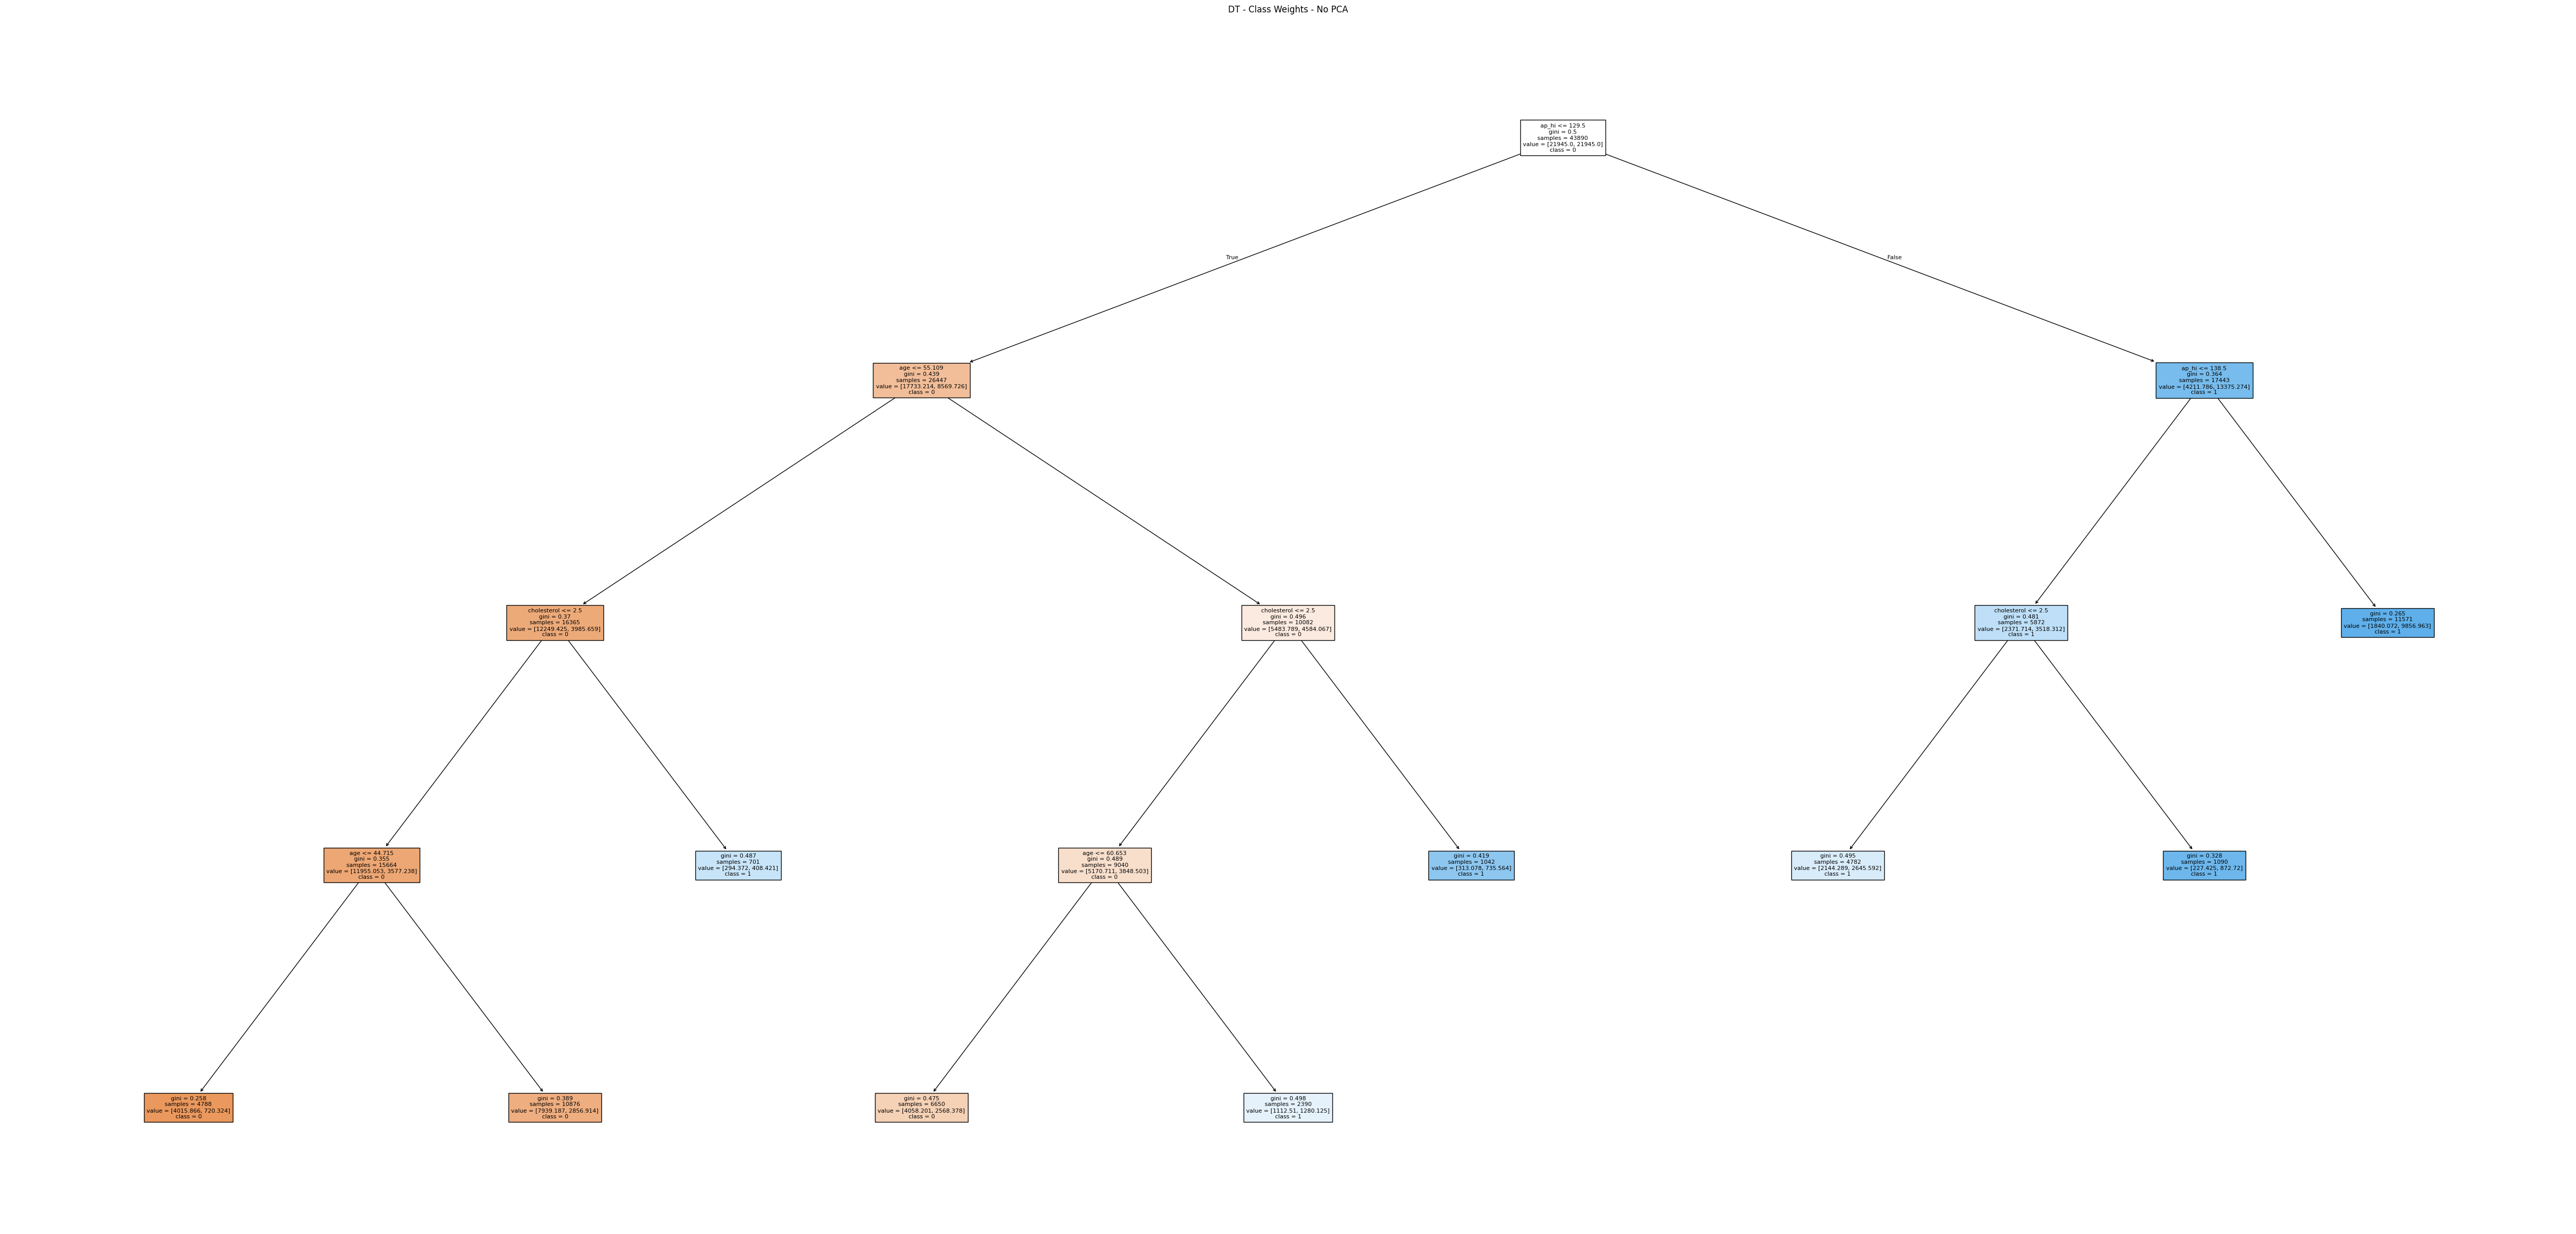

Accuracy: 0.7314
Profondità albero: 4
Numero di foglie: 9


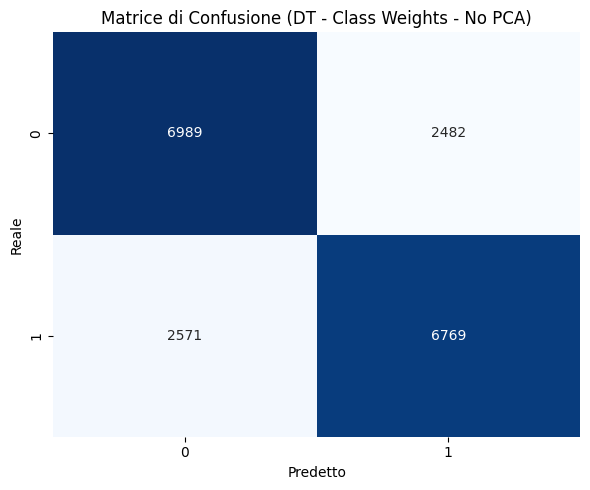


              precision    recall  f1-score   support

           0       0.73      0.74      0.73      9471
           1       0.73      0.72      0.73      9340

    accuracy                           0.73     18811
   macro avg       0.73      0.73      0.73     18811
weighted avg       0.73      0.73      0.73     18811



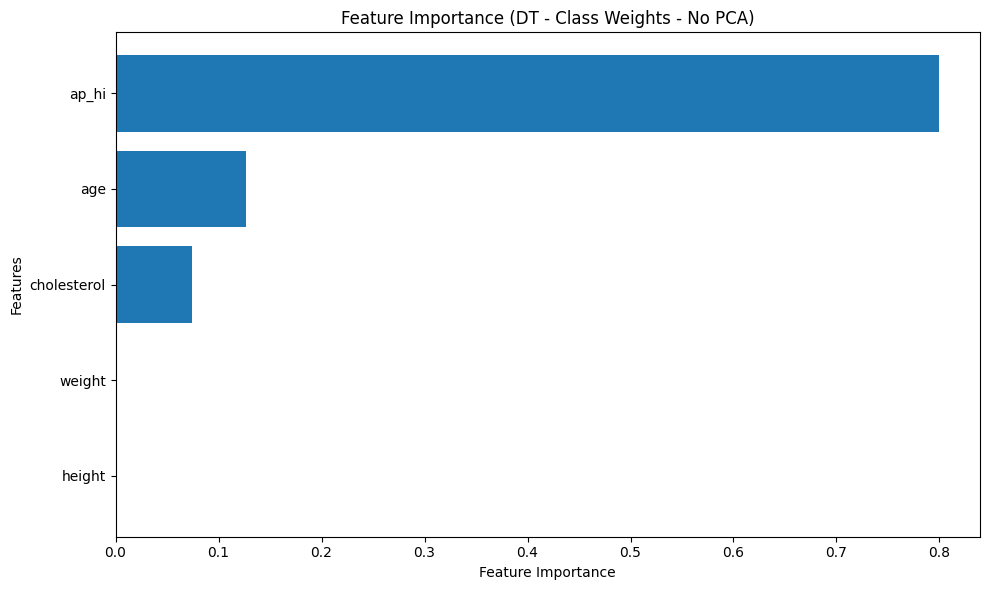


Feature Importance (DT - Class Weights - No PCA):
    feature  importance
      ap_hi    0.799367
        age    0.126849
cholesterol    0.073783
     weight    0.000000
     height    0.000000


In [ ]:
# Visualizza albero con class weights
print_tree(
    dt_class_weights,
    dt_class_weights.get_depth(),
    "DT - Class Weights - No PCA",
    all_features_dt,
)
show_tree_metrics(
    dt_class_weights, y_test_dt, y_pred_class_weights, "DT - Class Weights - No PCA"
)

plot_feature_importance(
    dt_class_weights, all_features_dt, "DT - Class Weights - No PCA", top_n=5
)

# Support Vector Machines (SVM)

Le Support Vector Machines sono algoritmi di machine learning supervisionato utilizzati per classificazione e regressione. L'obiettivo è trovare l'iperpiano ottimale che massimizza il margine tra le classi.

In [ ]:
# Import delle librerie necessarie per SVM
# (StandardScaler già importato nella sezione Reti Neurali)
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
import time

## Preparazione dei Dati

Le SVM richiedono dati scalati per funzionare correttamente, poiché sono sensibili alla scala delle features.
Riutilizziamo direttamente i dati già scalati delle Reti Neurali (`X_train_nn`, `X_test_nn`).

### Funzione di Utilità per SVM

Creiamo una funzione riutilizzabile per valutare e visualizzare le prestazioni dei modelli SVM, simile alle funzioni già definite per le reti neurali e gli alberi di decisione.

In [ ]:
# Funzione per valutare le prestazioni di un modello SVM (riutilizza funzioni esistenti)
def evaluate_svm(svm_model, X_test, y_test, y_pred, title_suffix):
    """
    Valuta e visualizza le metriche di performance di un modello SVM.
    Riutilizza la funzione show_tree_metrics già definita per gli alberi di decisione.
    """
    file_suffix = title_suffix.lower().replace(" ", "_").replace("-", "")

    # Calcola metriche
    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    print(f"\n{'='*60}")
    print(f"RISULTATI {title_suffix}")
    print(f"{'='*60}")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print(f"Numero di support vectors per classe: {svm_model.n_support_}")
    print(f"Totale support vectors: {sum(svm_model.n_support_)}")
    print(f"{'='*60}\n")

    # Riutilizza la visualizzazione confusion matrix e report di classificazione
    # già implementata in show_tree_metrics
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.xlabel("Predetto")
    plt.ylabel("Reale")
    plt.title(f"Matrice di Confusione ({title_suffix})")
    plt.tight_layout()
    plt.savefig(
        f"images/svm_confusion_matrix_{file_suffix}.svg",
        format="svg",
        bbox_inches="tight",
    )
    plt.show()

    print("\n" + classification_report(y_test, y_pred, target_names=["Sano", "Malato"]))

    return accuracy, f1, roc_auc

In [ ]:
# Riutilizziamo direttamente i dati già scalati delle Reti Neurali
X_train_svm = X_train_nn
X_test_svm = X_test_nn
y_train_svm = y_train_nn
y_test_svm = y_test_nn

print(f"SVM - Riutilizzo dei dati già scalati delle Reti Neurali")
print(f"Dimensioni training set: {X_train_svm.shape}")
print(f"Dimensioni test set: {X_test_svm.shape}")

SVM - Riutilizzo dei dati già scalati delle Reti Neurali
Dimensioni training set: (43890, 15)
Dimensioni test set: (18811, 15)


## SVM con Kernel Lineare

Iniziamo con un SVM a kernel lineare, adatto per dati linearmente separabili.

In [ ]:
# Training SVM con kernel lineare
print("Training SVM con kernel lineare...")
start_time = time.time()

svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_svm, y_train_svm)

training_time = time.time() - start_time
print(f"Tempo di training: {training_time:.2f} secondi")

# Predizioni
y_pred_linear = svm_linear.predict(X_test_svm)

Training SVM con kernel lineare...
Tempo di training: 87.27 secondi



RISULTATI SVM Linear Kernel
Accuracy: 0.7271
F1-Score: 0.6923
ROC-AUC: 0.7263
Numero di support vectors per classe: [14349 14348]
Totale support vectors: 28697



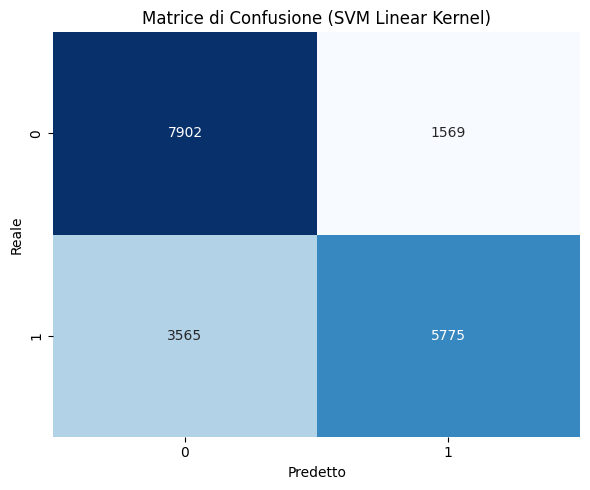


              precision    recall  f1-score   support

        Sano       0.69      0.83      0.75      9471
      Malato       0.79      0.62      0.69      9340

    accuracy                           0.73     18811
   macro avg       0.74      0.73      0.72     18811
weighted avg       0.74      0.73      0.72     18811



In [ ]:
# Valutazione usando la funzione riutilizzabile
accuracy_linear, f1_linear, roc_auc_linear = evaluate_svm(
    svm_linear, X_test_svm, y_test_svm, y_pred_linear, "SVM Linear Kernel"
)

## SVM con Kernel RBF (Radial Basis Function)

Il kernel RBF è utile per catturare relazioni non lineari nei dati.

In [ ]:
# Training SVM con kernel RBF
print("Training SVM con kernel RBF...")
start_time = time.time()

svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train_svm, y_train_svm)

training_time = time.time() - start_time
print(f"Tempo di training: {training_time:.2f} secondi")

# Predizioni
y_pred_rbf = svm_rbf.predict(X_test_svm)

Training SVM con kernel RBF...


KeyboardInterrupt: 


RISULTATI SVM RBF Kernel
Accuracy: 0.7322
F1-Score: 0.7103
ROC-AUC: 0.7313
Numero di support vectors per classe: [12813 13055]
Totale support vectors: 25868



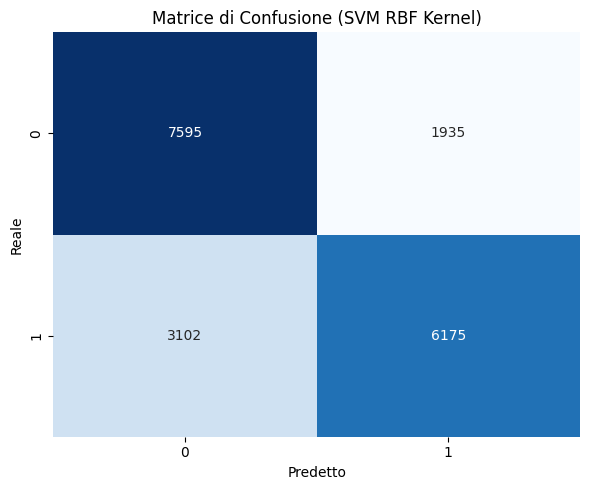


              precision    recall  f1-score   support

        Sano       0.71      0.80      0.75      9530
      Malato       0.76      0.67      0.71      9277

    accuracy                           0.73     18807
   macro avg       0.74      0.73      0.73     18807
weighted avg       0.74      0.73      0.73     18807



In [ ]:
# Valutazione usando la funzione riutilizzabile
accuracy_rbf, f1_rbf, roc_auc_rbf = evaluate_svm(
    svm_rbf, X_test_svm, y_test_svm, y_pred_rbf, "SVM RBF Kernel"
)

## Grid Search per Ottimizzazione degli Iperparametri

Utilizziamo Grid Search per trovare i migliori iperparametri per l'SVM con kernel RBF.

In [ ]:
# Grid Search per SVM (riutilizza GridSearchCV come per gli alberi di decisione)
from sklearn.model_selection import GridSearchCV

# Definizione della griglia di parametri
param_grid_svm = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.001, 0.01, 0.1, 1],
    "kernel": ["rbf"],
}

print("Esecuzione Grid Search per SVM...")
start_time = time.time()

# Grid Search con cross-validation (stessa impostazione degli alberi di decisione)
grid_svm = GridSearchCV(
    SVC(random_state=42), param_grid_svm, cv=5, scoring="f1", n_jobs=-1, verbose=1
)

grid_svm.fit(X_train_svm, y_train_svm)

grid_search_time = time.time() - start_time
print(f"\nTempo per Grid Search: {grid_search_time:.2f} secondi")

# Migliori parametri (stesso formato di output di run_grid_search)
print(f"\n{'='*60}")
print(f"RISULTATI GRID SEARCH (scoring=f1, cv=5)")
print(f"{'='*60}")
print(f"Migliori parametri: {grid_svm.best_params_}")
print(f"Miglior score (f1): {grid_svm.best_score_:.4f}")
print(f"{'='*60}\n")

Esecuzione Grid Search per SVM...
Fitting 5 folds for each of 24 candidates, totalling 120 fits


KeyboardInterrupt: 

In [ ]:
# Valutazione del modello ottimizzato
svm_best = grid_svm.best_estimator_
y_pred_best = svm_best.predict(X_test_svm)

In [ ]:
# Valutazione usando la funzione riutilizzabile
accuracy_best, f1_best, roc_auc_best = evaluate_svm(
    svm_best, X_test_svm, y_test_svm, y_pred_best, "SVM Ottimizzato (Grid Search)"
)

## SVM con Class Weight

Gestiamo lo sbilanciamento delle classi utilizzando il parametro `class_weight='balanced'`.

In [ ]:
# SVM con class_weight='balanced' (stesso approccio degli alberi di decisione)
print("Training SVM con class weight balanced...")
start_time = time.time()

svm_balanced = SVC(
    kernel="rbf",
    C=grid_svm.best_params_["C"],
    gamma=grid_svm.best_params_["gamma"],
    class_weight="balanced",
    random_state=42,
)
svm_balanced.fit(X_train_svm, y_train_svm)

training_time = time.time() - start_time
print(f"Tempo di training: {training_time:.2f} secondi")

# Predizioni
y_pred_balanced = svm_balanced.predict(X_test_svm)

In [ ]:
# Valutazione usando la funzione riutilizzabile
accuracy_balanced, f1_balanced, roc_auc_balanced = evaluate_svm(
    svm_balanced, X_test_svm, y_test_svm, y_pred_balanced, "SVM Balanced"
)

## Confronto dei Modelli SVM

Confrontiamo le prestazioni dei diversi modelli SVM implementati.

In [ ]:
# Creazione dataframe con i risultati
import pandas as pd

results_svm = pd.DataFrame(
    {
        "Modello": [
            "SVM Linear",
            "SVM RBF",
            "SVM Ottimizzato (Grid Search)",
            "SVM Balanced",
        ],
        "Accuracy": [accuracy_linear, accuracy_rbf, accuracy_best, accuracy_balanced],
        "F1-Score": [f1_linear, f1_rbf, f1_best, f1_balanced],
        "ROC-AUC": [roc_auc_linear, roc_auc_rbf, roc_auc_best, roc_auc_balanced],
        "Support Vectors": [
            sum(svm_linear.n_support_),
            sum(svm_rbf.n_support_),
            sum(svm_best.n_support_),
            sum(svm_balanced.n_support_),
        ],
    }
)

print("Confronto delle prestazioni dei modelli SVM:\n")
print(results_svm.to_string(index=False))

# Grafico a barre per confrontare le metriche
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Accuracy", "F1-Score", "ROC-AUC"]
colors = ["skyblue", "lightgreen", "lightcoral"]

for idx, (metric, color) in enumerate(zip(metrics, colors)):
    axes[idx].bar(results_svm["Modello"], results_svm[metric], color=color)
    axes[idx].set_title(f"Confronto {metric}", fontsize=12, fontweight="bold")
    axes[idx].set_ylabel(metric, fontsize=10)
    axes[idx].set_ylim([0.6, 0.8])
    axes[idx].tick_params(axis="x", rotation=45)
    axes[idx].grid(axis="y", alpha=0.3)

    # Aggiungi valori sopra le barre
    for i, v in enumerate(results_svm[metric]):
        axes[idx].text(i, v + 0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

## Conclusioni SVM

Le Support Vector Machines hanno mostrato buone prestazioni sui dati cardiovascolari. Alcuni punti chiave:

- **SVM Linear vs RBF**: Il kernel RBF tende a performare meglio grazie alla capacità di catturare relazioni non lineari.
- **Ottimizzazione**: Il Grid Search ha permesso di trovare i migliori iperparametri, migliorando le prestazioni del modello.
- **Class Weight**: L'utilizzo di `class_weight='balanced'` aiuta a gestire lo sbilanciamento delle classi, potenzialmente migliorando il recall sulla classe minoritaria.
- **Support Vectors**: Il numero di support vectors indica la complessità del modello e la difficoltà di separazione delle classi.

Le SVM sono particolarmente efficaci quando:
- Il numero di dimensioni è elevato
- I dati sono ben scalati
- È necessario un margine di separazione robusto tra le classi